In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
!pip install geopandas cartopy shapely

In [10]:
import sys
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [11]:
PROJECT_PATH = "/content/drive/MyDrive/cmip6-madagascar-projection"
sys.path.insert(0, PROJECT_PATH)

In [12]:
from src.config import *

DATA_PATH = "/content/drive/MyDrive/cmip6-madagascar-projection/data/regridded"
OUTPUT_PATH = "/content/drive/MyDrive/cmip6-madagascar-projection/outputs"

FIG_PATH = os.path.join(OUTPUT_PATH, "uncertain")

os.makedirs(FIG_PATH, exist_ok=True)

In [13]:
ts_models = []
pr_models = []

for model in MODELS:

    print("Loading:", model)

    ts_file = os.path.join(DATA_PATH, f"{model}_ts_ssp585_regridded.nc")
    pr_file = os.path.join(DATA_PATH, f"{model}_pr_ssp585_regridded.nc")

    ds_ts = xr.open_dataset(ts_file)
    ds_pr = xr.open_dataset(pr_file)

    ts = ds_ts["ts"]
    pr = ds_pr["pr"]

    # conversion unités
    ts = ts - 273.15

    seconds_per_day = 86400
    days_per_month = 30

    pr = pr * seconds_per_day * days_per_month

    # moyenne spatiale Afrique
    ts_mean = ts.mean(dim=["lat","lon"])
    pr_mean = pr.mean(dim=["lat","lon"])

    ts_models.append(ts_mean)
    pr_models.append(pr_mean)

Loading: CNRM-CM6-1
Loading: IPSL-CM6A-LR
Loading: MPI-ESM1-2-LR


In [14]:
ts_stack = xr.concat(ts_models, dim="model")
pr_stack = xr.concat(pr_models, dim="model")

In [15]:
ts_mean = ts_stack.mean("model")
ts_min = ts_stack.min("model")
ts_max = ts_stack.max("model")

pr_mean = pr_stack.mean("model")
pr_min = pr_stack.min("model")
pr_max = pr_stack.max("model")

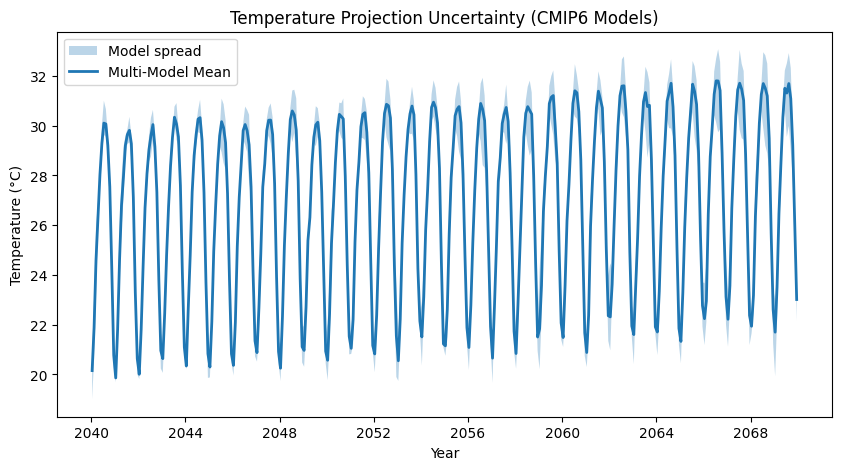

In [16]:
plt.figure(figsize=(10,5))

plt.fill_between(
    ts_mean.time,
    ts_min,
    ts_max,
    alpha=0.3,
    label="Model spread"
)

plt.plot(ts_mean.time, ts_mean, linewidth=2, label="Multi-Model Mean")

plt.title("Temperature Projection Uncertainty (CMIP6 Models)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Year")
plt.legend()

plt.savefig(os.path.join(FIG_PATH,"uncertainty_temperature.png"), dpi=300)
plt.show()

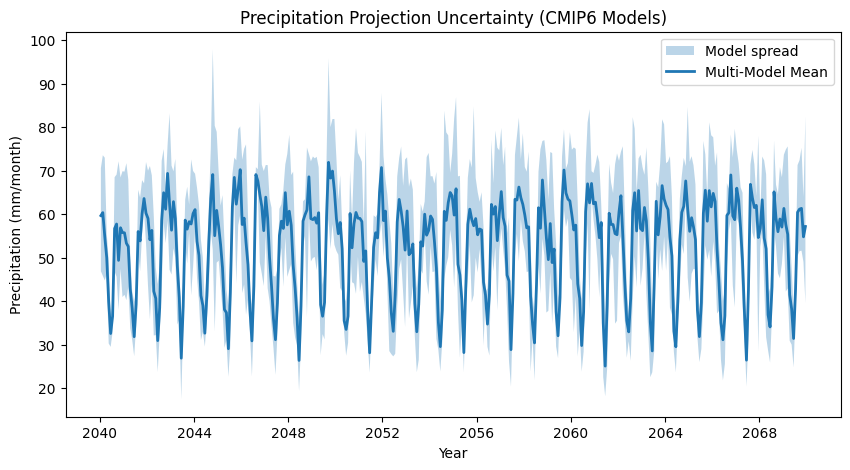

In [17]:
plt.figure(figsize=(10,5))

plt.fill_between(
    pr_mean.time,
    pr_min,
    pr_max,
    alpha=0.3,
    label="Model spread"
)

plt.plot(pr_mean.time, pr_mean, linewidth=2, label="Multi-Model Mean")

plt.title("Precipitation Projection Uncertainty (CMIP6 Models)")
plt.ylabel("Precipitation (mm/month)")
plt.xlabel("Year")
plt.legend()

plt.savefig(os.path.join(FIG_PATH,"uncertainty_precipitation.png"), dpi=300)
plt.show()

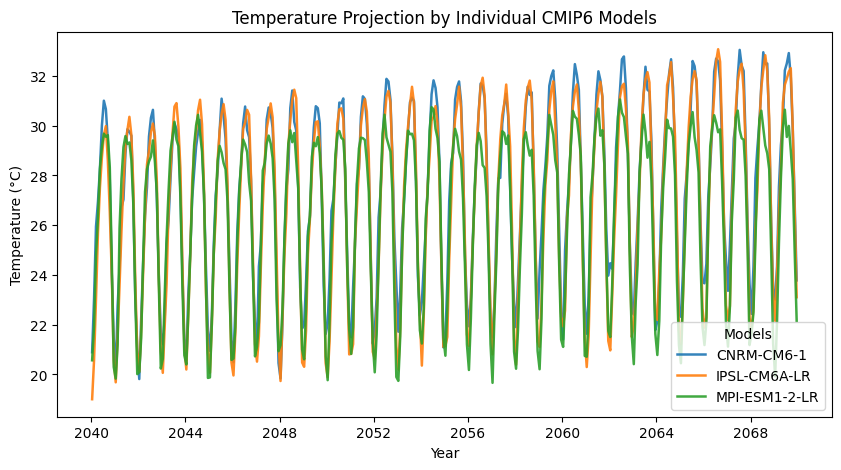

In [21]:
plt.figure(figsize=(10,5))

colors = ["tab:blue", "tab:orange", "tab:green"]

for i, model in enumerate(MODELS):

    plt.plot(
        ts_models[i].time,
        ts_models[i],
        linewidth=1.8,
        alpha=0.9,
        color=colors[i],
        label=model
    )

plt.title("Temperature Projection by Individual CMIP6 Models")
plt.ylabel("Temperature (°C)")
plt.xlabel("Year")

plt.legend(title="Models")

plt.savefig(
    os.path.join(FIG_PATH, "individual_models_temperature.png"),
    dpi=300
)

plt.show()

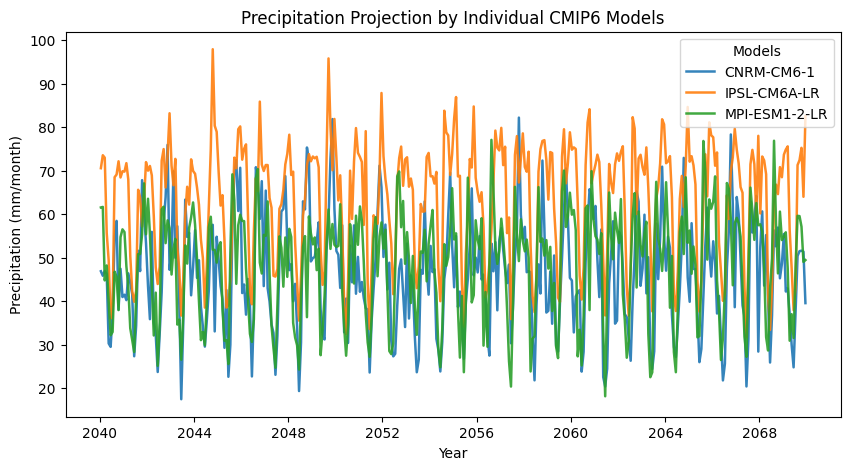

In [22]:

plt.figure(figsize=(10,5))

for i, model in enumerate(MODELS):

    plt.plot(
        pr_models[i].time,
        pr_models[i],
        linewidth=1.8,
        alpha=0.9,
        color=colors[i],
        label=model
    )

plt.title("Precipitation Projection by Individual CMIP6 Models")
plt.ylabel("Precipitation (mm/month)")
plt.xlabel("Year")

plt.legend(title="Models")

plt.savefig(
    os.path.join(FIG_PATH, "individual_models_precipitation.png"),
    dpi=300
)

plt.show()